# Mini Project 5-4 Explore confidence intervals

## Introduction

The Air Quality Index (AQI) is the Environmental Protection Agency's index for reporting air quality. A value close to 0 signals little to no public health concern, while higher values are associated with increased risk to public health. The United States is considering a new federal policy that would create a subsidy for renewable energy in states observing an average AQI of 10 or above. <br>

You've just started your new role as a data analyst in the Strategy division of Ripple Renewable Energy (RRE). **RRE operates in the following U.S. states: `California`, `Florida`, `Michigan`, `Ohio`, `Pennsylvania`, `Texas`.** You've been tasked with constructing an analysis which identifies which of these states are most likely to be affected, should the new federal policy be enacted.

Your manager has requested that you do the following for your analysis:
1. Provide a summary of the mean AQI for the states in which RRE operates.
2. Construct a boxplot visualization for AQI of these states using `seaborn`.
3. Evaluate which state(s) may be most affected by this policy, based on the data and your boxplot visualization.
4. Construct a confidence interval for the RRE state with the highest mean AQI.

## Step 1: Imports

### Import packages

Import `pandas` and `numpy`.

In [2]:
# Import relevant packages

import pandas as pd
import numpy as np

### Load the dataset

The dataset provided gives national Air Quality Index (AQI) measurements by state over time.  `Pandas` is used to import the file `c4_epa_air_quality.csv` as a DataFrame named `aqi`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

*Note: For the purposes of your analysis, you can assume this data is randomly sampled from a larger population.*

In [3]:
# Import data

air_quality = pd.read_csv("c4_epa_air_quality.csv")
air_quality.head()

,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3


## Step 2: Data exploration

### Explore your dataset

Before proceeding to your deliverables, spend some time exploring the `aqi` DataFrame. 

In [6]:
# Code Here

air_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        260 non-null    int64  
 1   date_local        260 non-null    object 
 2   state_name        260 non-null    object 
 3   county_name       260 non-null    object 
 4   city_name         260 non-null    object 
 5   local_site_name   257 non-null    object 
 6   parameter_name    260 non-null    object 
 7   units_of_measure  260 non-null    object 
 8   arithmetic_mean   260 non-null    float64
 9   aqi               260 non-null    int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 20.4+ KB


In [4]:
# Code Here

air_quality.isnull().sum()

Unnamed: 0          0
date_local          0
state_name          0
county_name         0
city_name           0
local_site_name     3
parameter_name      0
units_of_measure    0
arithmetic_mean     0
aqi                 0
dtype: int64

In [5]:
# Code Here

air_quality.describe()


,Unnamed: 0,arithmetic_mean,aqi
count,260.000000,260.000000,260.000000
mean,129.500000,0.403169,6.757692
std,75.199734,0.317902,7.061707
min,0.000000,0.000000,0.000000
25%,64.750000,0.200000,2.000000
50%,129.500000,0.276315,5.000000
75%,194.250000,0.516009,9.000000
max,259.000000,1.921053,50.000000


**Question:** What time range does this data cover?

In [8]:
# Code Here
air_quality['date'] = pd.to_datetime(air_quality['date_local'])

min_date = air_quality['date_local'].min()
max_date = air_quality['date_local'].max()

print("Date range:", min_date, "to", max_date)

Date range: 2018-01-01 to 2018-01-01


A: The data is all from 2018-01-01

**Question:** What are the minimum and maximum AQI values observed in the dataset?

In [9]:
# Code Here

min_aqi = air_quality['aqi'].min()
max_aqi = air_quality['aqi'].max()

print("Min aqi:", min_aqi)
print("Max aqi:", max_aqi)


Min aqi: 0
Max aqi: 50


**Question:** Are all states equally represented in the dataset?

In [10]:
# Code Here

state_counts = air_quality['state_name'].value_counts()

state_counts

state_name
California              66
Arizona                 14
Ohio                    12
Florida                 12
Texas                   10
Pennsylvania            10
New York                10
Colorado                 9
Michigan                 9
Minnesota                7
New Jersey               6
Indiana                  5
Nevada                   4
Maryland                 4
Massachusetts            4
Oklahoma                 4
North Carolina           4
Virginia                 4
Connecticut              4
Wyoming                  3
Utah                     3
Hawaii                   3
Illinois                 3
Missouri                 3
Iowa                     3
Kentucky                 3
Vermont                  3
Rhode Island             2
Alaska                   2
Georgia                  2
Washington               2
Idaho                    2
Nebraska                 2
Montana                  2
Tennessee                2
Maine                    2
New Mexico       

<function matplotlib.pyplot.show(close=None, block=None)>

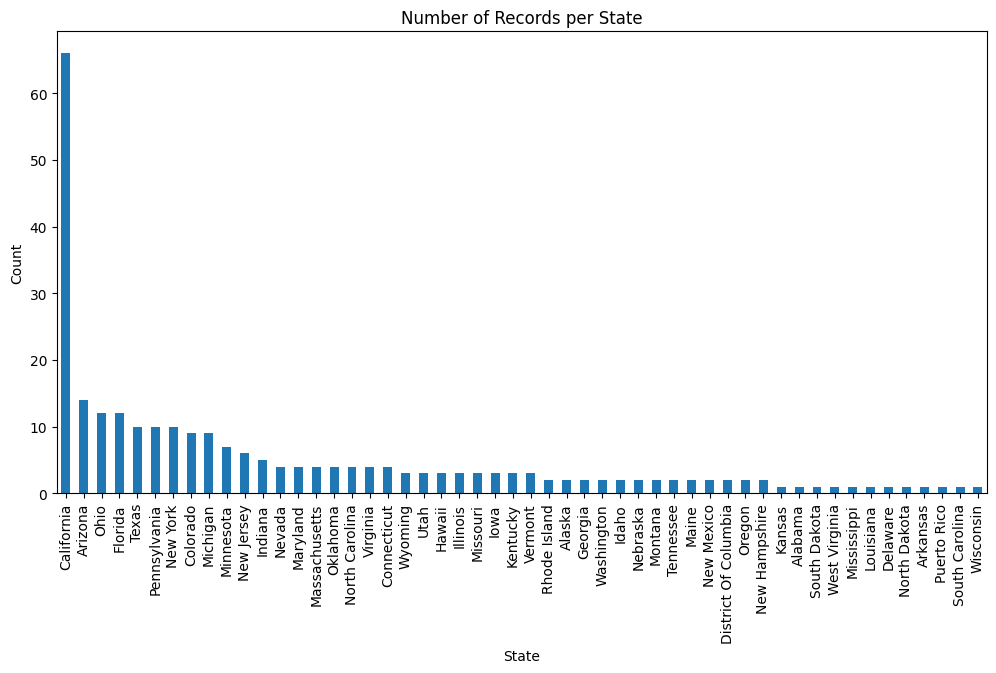

In [11]:
# Code Here

import matplotlib.pyplot as plt

state_counts.plot(kind='bar', figsize=(12, 6), title="Number of Records per State")
plt.xlabel("State")
plt.ylabel("Count")
plt.show

A: No all states are not equally represented. Some states have significantly more data points than others. 

## Step 3: Statistical tests

### Summarize the mean AQI for RRE states

Start with your first deliverable. Summarize the mean AQI for the states in which RRE operates (California, Florida, Michigan, Ohio, Pennsylvania, and Texas).

In [12]:
# Summarize the mean AQI for RRE states.

# Create a list of RRE states.

rre_states = ['California', 'Florida', 'Michigan', 'Ohio', 'Pennsylvania', 'Texas']

# Subset `aqi` to only consider these states.

aqi_rre = air_quality[air_quality['state_name'].isin(rre_states)]

# Find the mean aqi for each of the RRE states.
 #alias as aqi_rre

mean_aqi_by_state = aqi_rre.groupby('state_name')['aqi'].mean()

mean_aqi_by_state

state_name
California      12.121212
Florida          5.500000
Michigan         8.111111
Ohio             3.333333
Pennsylvania     2.900000
Texas            2.700000
Name: aqi, dtype: float64

### Construct a boxplot visualization for the AQI of these states

Seaborn is a simple visualization library, commonly imported as `sns`. Import `seaborn`. Then utilize a boxplot visualization from this library to compare the distributions of AQI scores by state.

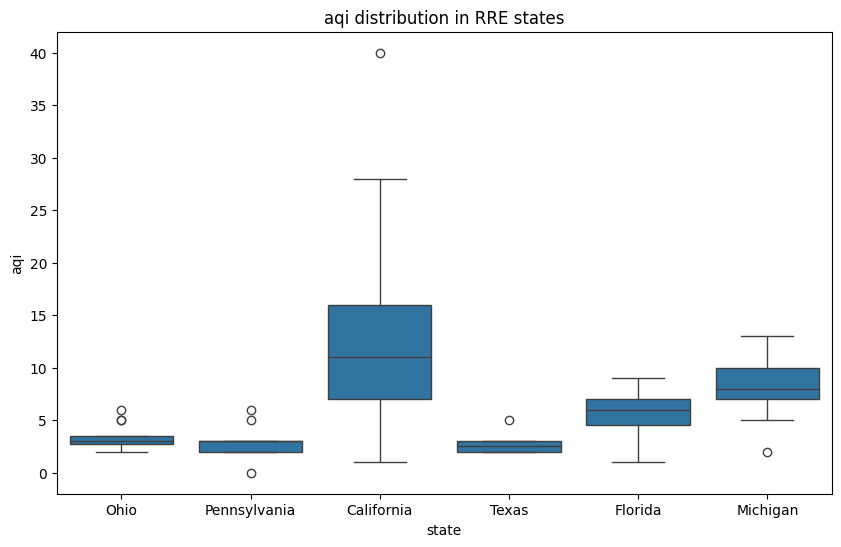

In [13]:
# Import seaborn as sns.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(data=aqi_rre, x='state_name', y='aqi')
plt.title("aqi distribution in RRE states")
plt.xlabel("state")
plt.ylabel("aqi")
plt.show()

### Create an in-line visualization showing the distribution of `aqi` by `state_name`

Now, create an in-line visualization showing the distribution of `aqi` by `state_name`.

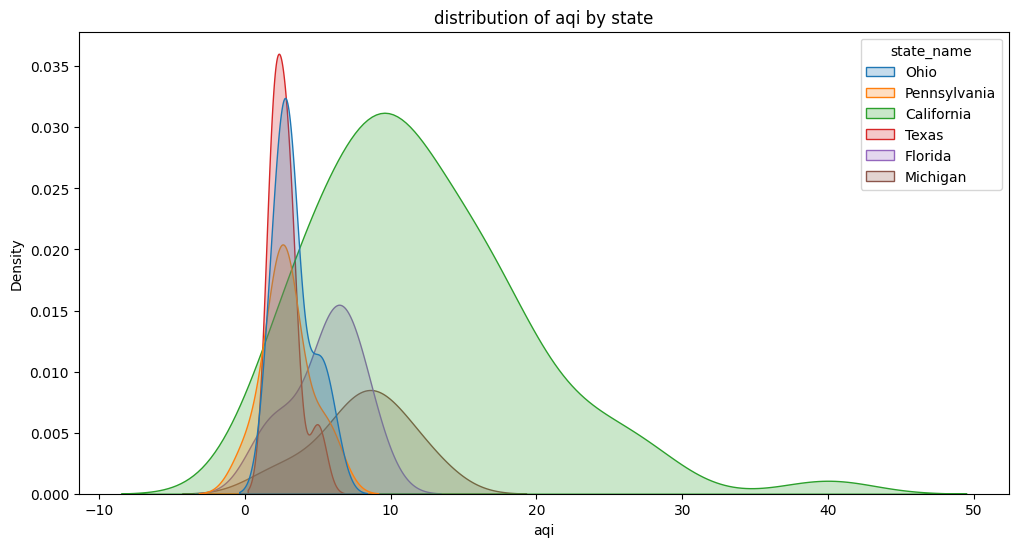

In [16]:
# Code Here

plt.figure(figsize=(12, 6))
sns.kdeplot(data=aqi_rre, x='aqi', hue='state_name', fill=True)
plt.title("distribution of aqi by state")
plt.xlabel("aqi")
plt.show()

**Question:** Based on the data and your visualizations, which state(s) do you suspect will be most affected by this policy?

A: California appears to be the state most likely affected by the policy. Its aqi is significantly higher and more spread out compared to the other RRE states.

### Construct a confidence interval for the RRE state with the highest mean AQI

Recall the 4-step process in constructing a confidence interval:

1.   Identify a sample statistic.
2.   Choose a confidence level.
3.   Find the margin of error. 
4.   Calculate the interval.

### Construct your sample statistic

To contruct your sample statistic, find the mean AQI for CA.

In [17]:
# Find the mean aqi for CA state.

ca_data = aqi_rre[aqi_rre['state_name'] == 'California']

ca_mean = ca_data['aqi'].mean()
ca_mean

np.float64(12.121212121212121)

### Choose your confidence level

Choose your confidence level for your analysis. The most typical confidence level chosen is 95%; however, you can choose 90% or 99% if you want decrease or increase (respectively) your level of confidence about your result.

In [18]:
# Input your confidence level here:

confidence = 0.95

### Find your margin of error (ME)

Recall **margin of error = z * standard error**, where z is the appropriate z-value for the given confidence level. To calculate your margin of error:

- Find your z-value. 
- Find the approximate z for common confidence levels.
- Calculate your **standard error** estimate. 

| Confidence Level | Z Score |
| --- | --- |
| 90% | 1.65 |
| 95% | 1.96 |
| 99% | 2.58 |


In [19]:
# Calculate your margin of error.

# Begin by identifying the z associated with your chosen confidence level.

z_value = 1.96

# Next, calculate your standard error.

std_dev = ca_data['aqi'].std()
n = len(ca_data)

standard_error = std_dev / np.sqrt(n)

# Lastly, use the preceding result to calculate your margin of error.

margin_of_error = z_value * standard_error

print("margin of error", margin_of_error)


margin of error 1.7614930896609726


### Calculate your interval

Calculate both a lower and upper limit surrounding your sample mean to create your interval.

In [20]:
# Calculate your confidence interval (upper and lower limits).

ca_mean = ca_data['aqi'].mean()

lower_limit = ca_mean - margin_of_error
upper_limit = ca_mean + margin_of_error

print(f"95% Confidence Interval for CA mean aqi: ({lower_limit:.2f}, {upper_limit:.2f})")

95% Confidence Interval for CA mean aqi: (10.36, 13.88)


### Alternative: Construct the interval using `scipy.stats.norm.interval()`

`scipy` presents a simpler solution to developing a confidence interval. To use this, first import the `stats` module from `scipy`.

In [21]:
# Import stats from scipy.

from scipy import stats

## Step 4: Results and evaluation

### Recalculate your confidence interval

Provide your chosen `confidence_level`, `sample_mean`, and `standard_error` to `stats.norm.interval()` and recalculate your confidence interval.

In [24]:
# Code Here

confidence = 0.95 
ca_mean = ca_data['aqi'].mean()
standard_error = ca_data['aqi'].std() / np.sqrt(len(ca_data))

ci_lower, ci_upper = stats.norm.interval(confidence, loc=ca_mean, scale=standard_error)
print(f"95% confidence interval for mean aqi in california:({ci_lower:.2f}, {ci_upper:.2f})")


95% confidence interval for mean aqi in california:(10.36, 13.88)


# Considerations

**What are some key takeaways that you learned from this project?**

A: Learned calculating summary statistics, creating visualizations - boxplots and KDE plots, and constructing confidence intervals. Also, how data can be used to support public policy decisions.  

**What findings would you share with others?**

A: I would share that California has significantly higher and more variable aqi values compared to other rre states. This suggests a greater public health concern and stronger case for renewable energy support. States like Pennsylvania and Florida showed relatively lower aqi values and may be less impacted by the policy. 

**What would you convey to external readers?**

A: The analysis highlights the importance of using data-driven insights to shape environmental policy. By identifying states with the highest air quality concerns, decision-makers can better allocate resources. Findings suggest that California, specifically, would likely be a key beneficiary of the proposed federal subsidy program for renewable energy.

**References**

[seaborn.boxplot — seaborn 0.12.1 documentation](https://seaborn.pydata.org/generated/seaborn.boxplot.html). (n.d.). 